In [223]:
import numpy as np                                                                 
import pandas as pd
import matplotlib.pyplot as  plt
import seaborn as sns

In [224]:
df= pd.read_csv("customer_segmentation.csv")

In [225]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [226]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [227]:
df.shape

(2240, 29)

In [228]:
df.isna().sum().sum()

np.int64(24)

In [229]:
df.dropna(inplace=True)

In [230]:
df.isna().sum().sum()

np.int64(0)

In [231]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [232]:
df["Education"].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [233]:
df["Marital_Status"].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [234]:
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)

In [235]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [236]:
df["Age"]= 2025-df["Year_Birth"]

In [237]:
df["Age"]

0       68
1       71
2       60
3       41
4       44
        ..
2235    58
2236    79
2237    44
2238    69
2239    71
Name: Age, Length: 2216, dtype: int64

In [238]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,68
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,71
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,3,11,0,60
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,3,11,0,41
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,3,11,0,44


In [239]:
df["Total_children"]=df["Kidhome"]+ df["Teenhome"]

In [240]:
df["Total_children"]


0       0
1       2
2       0
3       1
4       1
       ..
2235    1
2236    3
2237    0
2238    1
2239    2
Name: Total_children, Length: 2216, dtype: int64

In [241]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_children'],
      dtype='object')

In [242]:
spend_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

In [243]:
df["Total_spending"]= df[spend_cols].sum(axis=1)

In [244]:
df["Total_spending"]

0       1617
1         27
2        776
3         53
4        422
        ... 
2235    1341
2236     444
2237    1241
2238     843
2239     172
Name: Total_spending, Length: 2216, dtype: int64

In [245]:
df["Customer_since"]=(pd.Timestamp("today")-df["Dt_Customer"]).dt.days

In [246]:
df["Customer_since"]

0       5146
1       4596
2       4795
3       4622
4       4644
        ... 
2235    4864
2236    4502
2237    4638
2238    4639
2239    5105
Name: Customer_since, Length: 2216, dtype: int64

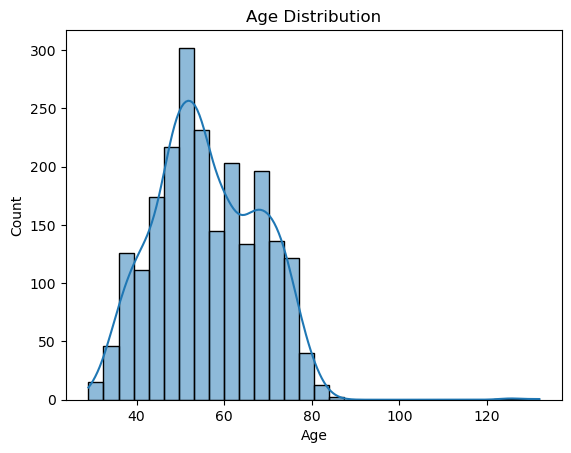

In [247]:
sns.histplot(df["Age"],bins=30,kde=True)
plt.title("Age Distribution")
plt.show()

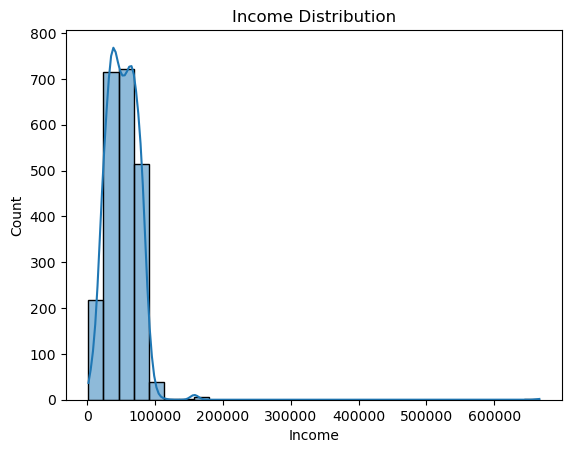

In [248]:
sns.histplot(df["Income"],bins=30,kde=True)
plt.title("Income Distribution")
plt.show()

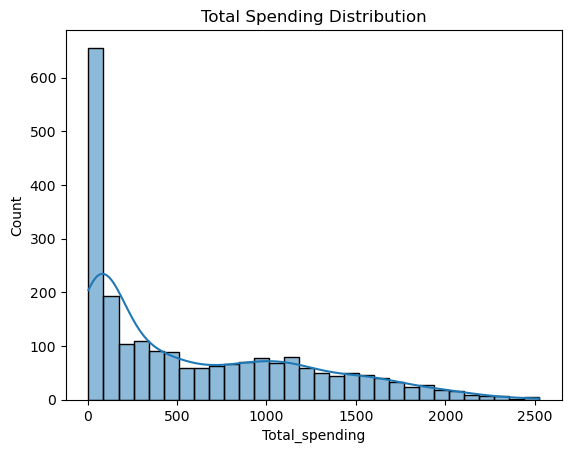

In [249]:
sns.histplot(df["Total_spending"],bins=30,kde=True)
plt.title("Total Spending Distribution")
plt.show()

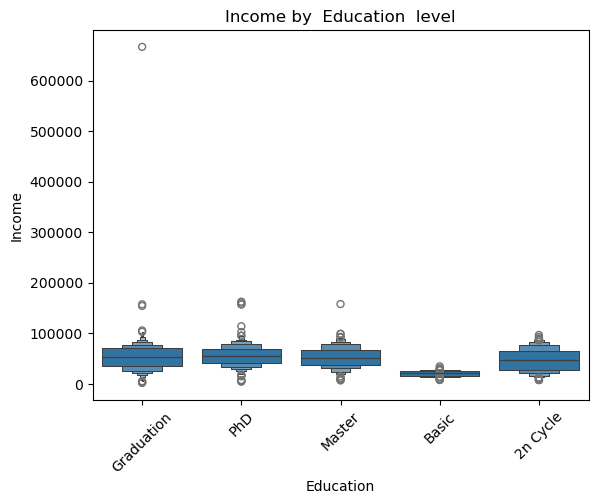

In [250]:
sns.boxenplot( x="Education",y= "Income",data=df)
plt.xticks(rotation=45)
plt.title("Income by  Education  level")
plt.show()

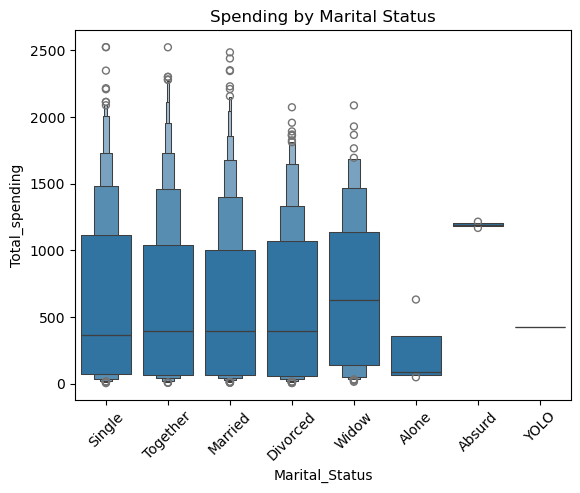

In [251]:
sns.boxenplot( x="Marital_Status",y= "Total_spending",data=df)
plt.xticks(rotation=45)
plt.title("Spending by Marital Status")
plt.show()

In [252]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_children', 'Total_spending', 'Customer_since'],
      dtype='object')

In [253]:
corr=df[["Income","Age","Recency","Total_spending","NumWebPurchases","NumStorePurchases"]]

In [254]:
corr

,Income,Age,Recency,Total_spending,NumWebPurchases,NumStorePurchases
0,58138.0,68,58,1617,8,4
1,46344.0,71,38,27,1,2
2,71613.0,60,26,776,8,10
3,26646.0,41,26,53,2,4
4,58293.0,44,94,422,5,6
...,...,...,...,...,...,...
2235,61223.0,58,46,1341,9,4
2236,64014.0,79,56,444,8,5
2237,56981.0,44,91,1241,2,13
2238,69245.0,69,8,843,6,10


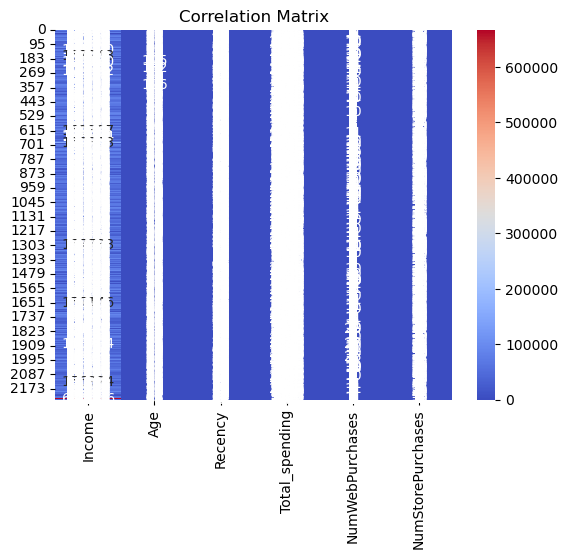

In [255]:
sns.heatmap(corr, annot=True, fmt=".0f", cmap="coolwarm",
            )
plt.title('Correlation Matrix')
plt.show()

In [256]:
pivot_income=df.pivot_table(values= "Income",index="Education",columns="Marital_Status",aggfunc="mean")

In [257]:
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


Text(0.5, 1.0, 'Average income by Education and Martinal Status')

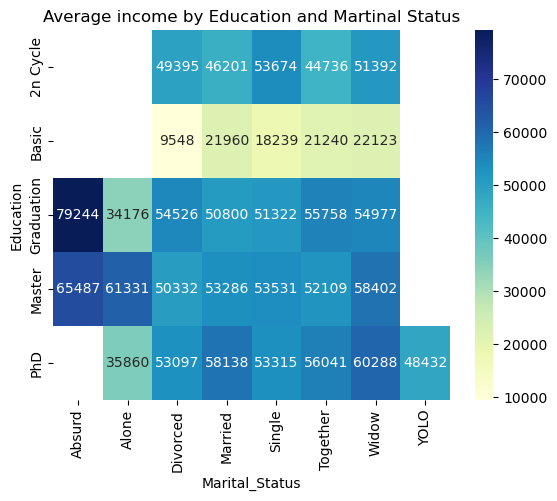

In [258]:
sns.heatmap(pivot_income,annot=True ,fmt=".0f",cmap="YlGnBu")
plt.title("Average income by Education and Martinal Status")

In [259]:
group1= df.groupby("Education")["Total_spending"].mean().sort_values(ascending= False)

In [260]:
group1

Education
PhD           676.733888
Graduation    621.686380
Master        609.767123
2n Cycle      494.930000
Basic          81.796296
Name: Total_spending, dtype: float64

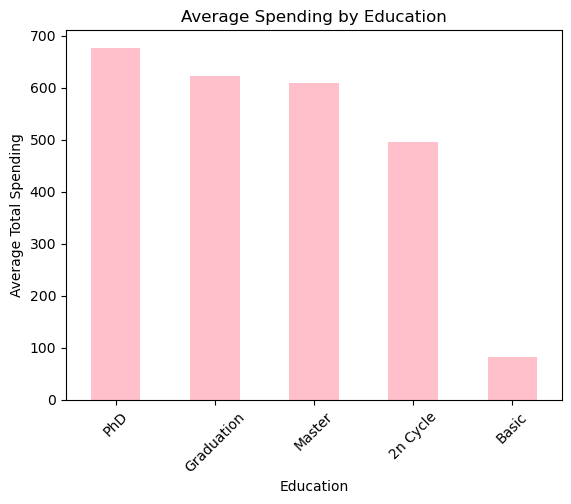

In [261]:
group1.plot(kind="bar",color="Pink")
plt.title("Average Spending by Education")
plt.ylabel("Average Total Spending")
plt.xticks(rotation=45)
plt.show()

In [262]:
df["AcceptedAny"]=df[["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Response"]].sum(axis=1)

In [263]:
df["AcceptedAny"].unique()

array([1, 0, 3, 2, 4, 5])

In [264]:
df["AcceptedAny"]=df["AcceptedAny"].apply(lambda x:1 if x>0 else 0)

In [265]:
df["AcceptedAny"].unique()


array([1, 0])

In [266]:
group2= df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending= False)

In [267]:
group2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.342105
Alone       0.333333
Single      0.312102
Divorced    0.297414
Married     0.252042
Together    0.251309
Name: AcceptedAny, dtype: float64

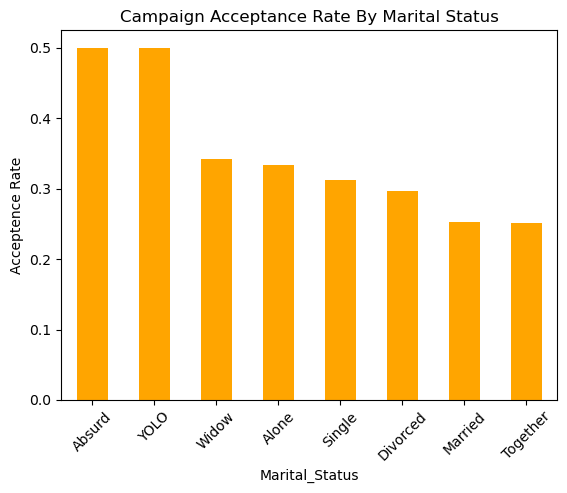

In [268]:
group2.plot(kind="bar",color="orange")
plt.title("Campaign Acceptance Rate By Marital Status")
plt.ylabel("Acceptence Rate")
plt.xticks(rotation=45)
plt.show()

In [269]:
bins=[18,30,40,50,60,70,90]

In [270]:
labels= ["18-29","30-39","40-49","50-59","60-69","70+"]

In [271]:
df["AgeGroup"]=pd.cut(df["Age"],bins=bins,labels=labels)

In [272]:
df["AgeGroup"]

0       60-69
1         70+
2       50-59
3       40-49
4       40-49
        ...  
2235    50-59
2236      70+
2237    40-49
2238    60-69
2239      70+
Name: AgeGroup, Length: 2216, dtype: category
Categories (6, object): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

In [273]:
group3= df.groupby("AgeGroup")["Income"].mean()

C:\Users\anshu kumari\AppData\Local\Temp\ipykernel_14332\3195967181.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group3= df.groupby("AgeGroup")["Income"].mean()


In [274]:
group3

AgeGroup
18-29    46658.000000
30-39    46283.028302
40-49    49224.877034
50-59    50812.913303
60-69    56200.827887
70+      58944.316294
Name: Income, dtype: float64

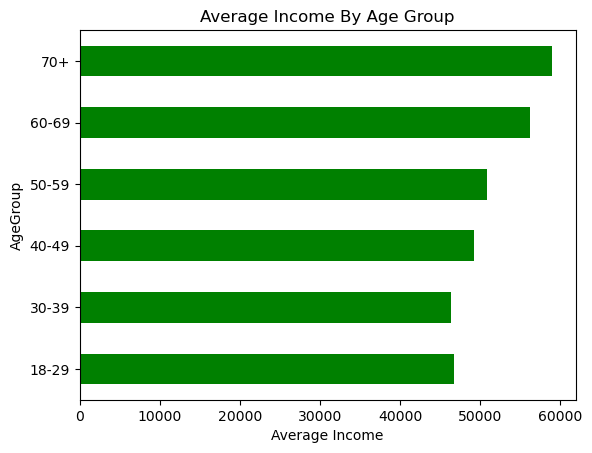

In [275]:
group3.plot(kind="barh",color="green")
plt.title("Average Income By Age Group")
plt.xlabel("Average Income")

plt.show()

In [276]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_children,Total_spending,Customer_since,AcceptedAny,AgeGroup
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,3,11,1,68,0,1617,5146,1,60-69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,3,11,0,71,2,27,4596,0,70+
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,3,11,0,60,0,776,4795,0,50-59
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,3,11,0,41,1,53,4622,0,40-49
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,3,11,0,44,1,422,4644,0,40-49


In [277]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_children', 'Total_spending', 'Customer_since',
       'AcceptedAny', 'AgeGroup'],
      dtype='object')

In [278]:
#Age - Income -Total_spending- NumWebPurchases- NumStorePurchases - NumWebVisitsMonth - Recency

In [301]:
features =["Age", "Income","Total_spending", "NumWebPurchases", "NumStorePurchases", "NumWebVisitsMonth","Recency"]

In [302]:
x=df[features].copy()

In [303]:
x

,Age,Income,Total_spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,68,58138.0,1617,8,4,7,58
1,71,46344.0,27,1,2,5,38
2,60,71613.0,776,8,10,4,26
3,41,26646.0,53,2,4,6,26
4,44,58293.0,422,5,6,5,94
...,...,...,...,...,...,...,...
2235,58,61223.0,1341,9,4,5,46
2236,79,64014.0,444,8,5,7,56
2237,44,56981.0,1241,2,13,6,91
2238,69,69245.0,843,6,10,3,8


In [304]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [305]:
x_scaled= scaler.fit_transform(x)

In [306]:
x_scaled

array([[ 0.98644293,  0.2340627 ,  1.67548812, ..., -0.55414289,
         0.69323197,  0.31053212],
       [ 1.23680074, -0.23455948, -0.96235832, ..., -1.16951781,
        -0.1315745 , -0.38050944],
       [ 0.31882209,  0.76947764,  0.28024985, ...,  1.29198186,
        -0.54397773, -0.79513438],
       ...,
       [-1.01641959,  0.18809052,  1.05169551, ...,  2.21504423,
         0.28082874,  1.4507507 ],
       [ 1.06989553,  0.67538765,  0.39140438, ...,  1.29198186,
        -0.95638097, -1.41707178],
       [ 1.23680074,  0.02470453, -0.7218    , ..., -0.55414289,
         0.69323197, -0.31140528]], shape=(2216, 7))

In [307]:
from sklearn.cluster import KMeans

In [308]:
wcss=[]

In [309]:
for i in range(2,10):
    kmeans= KMeans(n_clusters=i)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

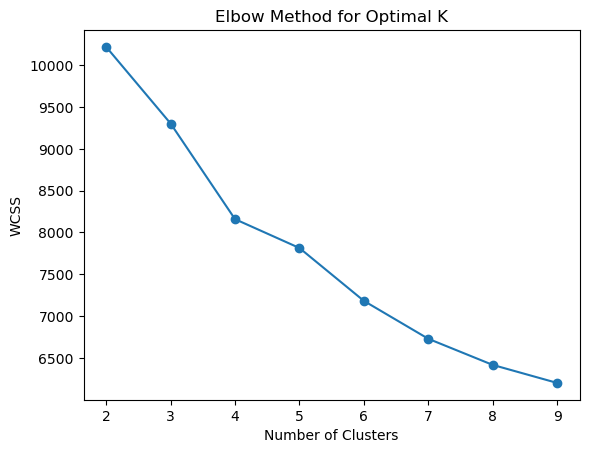

In [310]:
plt.plot(range(2,10),wcss,marker= "o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [311]:
kmeans=KMeans(n_clusters=6)
df["Cluster"] = kmeans.fit_predict(x_scaled)

In [312]:
df["Cluster"]

0       2
1       0
2       5
3       0
4       1
       ..
2235    2
2236    5
2237    2
2238    3
2239    1
Name: Cluster, Length: 2216, dtype: int32

In [313]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Response,Age,Total_children,Total_spending,Customer_since,AcceptedAny,AgeGroup,Cluster,PCA1,PCA2
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,1,68,0,1617,5146,1,60-69,2,1.105180,1.630211
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,71,2,27,4596,0,70+,0,-1.334009,-0.209708
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,60,0,776,4795,0,50-59,5,1.888414,0.639592
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,41,1,53,4622,0,40-49,0,-1.778358,-0.717599
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,44,1,422,4644,0,40-49,1,0.008670,-0.383926


In [314]:
cluster_summary =df.groupby("Cluster")[features].mean()

In [315]:
cluster_summary

,Age,Income,Total_spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,50.875940,32169.127820,88.686090,1.941729,3.041353,6.635338,26.620301
1,56.057143,37141.561905,136.841905,2.455238,3.504762,6.358095,75.491429
2,56.910448,62097.283582,1021.440299,7.779851,8.888060,6.052239,69.167910
3,69.788194,74188.475694,1182.364583,4.340278,8.298611,2.350694,53.173611
4,46.088525,79447.609836,1326.022951,4.547541,8.488525,2.521311,45.924590
5,62.382550,56801.137584,696.483221,6.741611,6.832215,6.211409,23.352349


In [316]:
df["Cluster"].value_counts()

Cluster
0    532
1    525
4    305
5    298
3    288
2    268
Name: count, dtype: int64

In [317]:
from sklearn.decomposition import PCA

pca= PCA(n_components=2)
pca_data= pca.fit_transform(x_scaled)
df["PCA1"],df["PCA2"]= pca_data[:,0],pca_data[:,1]

In [318]:
pca_data

array([[ 1.1075188 , -0.21175951],
       [-1.33673385,  0.269839  ],
       [ 1.88227676, -1.01416098],
       ...,
       [ 1.1535966 ,  1.15056999],
       [ 1.88768024, -1.16073698],
       [-0.84182091, -0.15963623]], shape=(2216, 2))

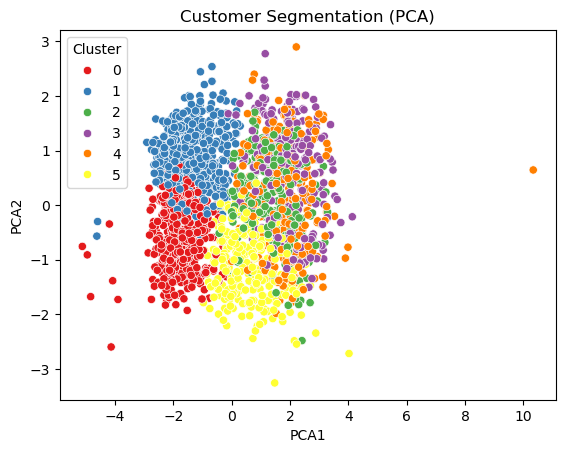

In [319]:
sns.scatterplot(x="PCA1",y="PCA2",hue ="Cluster",data = df, palette="Set1")
plt.title("Customer Segmentation (PCA)")
plt.show()

In [320]:
cluster_summary

,Age,Income,Total_spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,50.875940,32169.127820,88.686090,1.941729,3.041353,6.635338,26.620301
1,56.057143,37141.561905,136.841905,2.455238,3.504762,6.358095,75.491429
2,56.910448,62097.283582,1021.440299,7.779851,8.888060,6.052239,69.167910
3,69.788194,74188.475694,1182.364583,4.340278,8.298611,2.350694,53.173611
4,46.088525,79447.609836,1326.022951,4.547541,8.488525,2.521311,45.924590
5,62.382550,56801.137584,696.483221,6.741611,6.832215,6.211409,23.352349


In [321]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']